# Working with Text Data


Follow _Introduction to Machine Learning_ [Chapter 7](https://github.com/amueller/introduction_to_ml_with_python/blob/master/07-working-with-text-data.ipynb):
-  Chapter 7. Working with text data - 7.7 Bag of Words with more than one word (p.329-350)


We will look at supervised classification of text features, in particular sentiment analysis. Given a text commenting on a movie, is this a *positive* or a *negative* comment.

Similar problems include for example, given an email text, is this *spam* or *legitimate* message.

Our classifiers will only accept numerical features as input. Therefore, we have to **transform** text to a **number representation** first.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import mglearn

## Download the IMDb data

>As a running example in this chapter, we will use a dataset of movie reviews from the IMDb (Internet Movie Database) website collected by Stanford researcher Andrew Maas.3 This dataset contains the text of the reviews, together with a label that indicates whether a review is “positive” or “negative.” The IMDb website itself contains ratings from 1 to 10. To simplify the modeling, this annotation is summarized as a two-class classification dataset where reviews with a score of 7 or higher are labeled as positive, and a score 4 or lower is labeled as negative (neutral reviews are not included in the dataset). We will leave the question of whether this is a good representation of the data open, and simply use the data as provided by Andrew Maas.

On Mac you can use the cell below. On Windows you need to manually download from http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz

The dataset is ~80MB

In [3]:
#! curl -O http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
#! mkdir data
#! tar xzf aclImdb_v1.tar.gz -C data

In [4]:
#!tree -dL 2 data/aclImdb

In [5]:
#!rm -r data/aclImdb/train/unsup

In [6]:
#!tree -dL 2 data/aclImdb

### Load the training set

In [7]:
from sklearn.datasets import load_files

reviews_train = load_files("data/aclImdb/train/")
# load_files returns a bunch, containing training texts and training labels
text, tar = reviews_train.data, reviews_train.target
print("type of text_train: {}".format(type(text)))
print("length of text_train: {}".format(len(text)))
print("text_train[6]:\n{}".format(text[6]))

type of text_train: <class 'list'>
length of text_train: 75000
text_train[6]:
b'Gloomy Sunday - Ein Lied von Liebe und Tod directed by Rolf Sch\xc3\xbcbel in 1999 is a romantic, absorbing, beautiful, and heartbreaking movie. It started like Jules and Jim; it ended as one of Agatha Christie\'s books, and in between it said something about love, friendship, devotion, jealousy, war, Holocaust, dignity, and betrayal, and it did better than The Black Book which is much more popular. It is not perfect, and it made me, a cynic, wonder in the end on the complexity of the relationships and sensational revelations, and who is who to whom but the movie simply overwhelmed me. Perfect or not, it is unforgettable. All four actors as the parts of the tragic not even a triangle but a rectangle were terrific. I do believe that three men could fell deeply for one girl as beautiful and dignified as Ilona in a star-making performance by young Hungarian actress Erica Marozs\xc3\xa1n and who would not? The 

In [8]:
text = [doc.replace(b"<br />", b" ") for doc in text]

In [9]:
print("Samples per class (training): {}".format(np.bincount(tar)))

Samples per class (training): [12500 12500 50000]


In [10]:
print("y_train[6]:\n{}".format(tar[6]))

y_train[6]:
2


In [11]:
reviews_train.target_names

['neg', 'pos', 'unsup']

In [12]:
np.unique(tar)

array([0, 1, 2])

In [13]:
# We need to remove the unsupported reviews (Only for Windows)
text_train = [text[i] for i in range(len(text)) if tar[i] != 2]
y_train = [tar[i] for i in range(len(tar)) if tar[i] != 2]

In [14]:
# Check to make sure the lengths are the same
print(len(text_train))
print(len(y_train))

25000
25000


### Load the test set

In [15]:
reviews_test = load_files("data/aclImdb/test/")
text_test, y_test = reviews_test.data, reviews_test.target
print("Number of documents in test data: {}".format(len(text_test)))
print("Samples per class (test): {}".format(np.bincount(y_test)))
text_test = [doc.replace(b"<br />", b" ") for doc in text_test]

Number of documents in test data: 25000
Samples per class (test): [12500 12500]


## Bag of words
Computing the bag-of-words representation for a **corpus** of **documents** consists of the following three steps:

1. Tokenization. Split each document into the words that appear in it (called tokens), for example by splitting them on whitespace and punctuation.

2. Vocabulary building. Collect a vocabulary of all words that appear in any of the documents, and number them (say, in alphabetical order).

3. Encoding. For each document, count how often each of the words in the vocabulary appear in this document.

In [16]:
from sklearn.feature_extraction.text import CountVectorizer
vect = CountVectorizer().fit(text_train)
X_train = vect.transform(text_train)
print("X_train:\n{}".format(repr(X_train)))

X_train:
<25000x74849 sparse matrix of type '<class 'numpy.int64'>'
	with 3431196 stored elements in Compressed Sparse Row format>


>The shape of X_train, the bag-of-words representation of the training data, is 25,000×74,849, indicating that the vocabulary contains 74,849 entries. Again, the data is stored as a SciPy sparse matrix. Let’s look at the vocabulary in a bit more detail. Another way to access the vocabulary is using the get_feature_name method of the vectorizer, which returns a convenient list where each entry corresponds to one feature:

In [17]:
feature_names = vect.get_feature_names_out()
print("Number of features: {}".format(len(feature_names)))
print("First 20 features:\n{}".format(feature_names[:20]))
print("Features 20010 to 20030:\n{}".format(feature_names[20010:20030]))
print("Every 2000th feature:\n{}".format(feature_names[::2000]))

Number of features: 74849
First 20 features:
['00' '000' '0000000000001' '00001' '00015' '000s' '001' '003830' '006'
 '007' '0079' '0080' '0083' '0093638' '00am' '00pm' '00s' '01' '01pm' '02']
Features 20010 to 20030:
['dratted' 'draub' 'draught' 'draughts' 'draughtswoman' 'draw' 'drawback'
 'drawbacks' 'drawer' 'drawers' 'drawing' 'drawings' 'drawl' 'drawled'
 'drawling' 'drawn' 'draws' 'draza' 'dre' 'drea']
Every 2000th feature:
['00' 'aesir' 'aquarian' 'barking' 'blustering' 'bête' 'chicanery'
 'condensing' 'cunning' 'detox' 'draper' 'enshrined' 'favorit' 'freezer'
 'goldman' 'hasan' 'huitieme' 'intelligible' 'kantrowitz' 'lawful' 'maars'
 'megalunged' 'mostey' 'norrland' 'padilla' 'pincher' 'promisingly'
 'receptionist' 'rivals' 'schnaas' 'shunning' 'sparse' 'subset'
 'temptations' 'treatises' 'unproven' 'walkman' 'xylophonist']


## Train a classifier

**Note:** We can get away with not building a pipeline, because `CountVectorizer()` with default parameters does not use any statistics of the dataset. However, building a pipeline would be preferred. We do this later.

In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
scores = cross_val_score(LogisticRegression(max_iter=5000), X_train, y_train, cv=5)
print("Mean cross-validation accuracy: {:.2f}".format(np.mean(scores)))

Mean cross-validation accuracy: 0.88


>We obtain a mean cross-validation score of 88%, which indicates reasonable performance for a balanced binary classification task. We know that LogisticRegression has a regularization parameter, C, which we can tune via cross-validation:

In [19]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10]}
grid = GridSearchCV(LogisticRegression(max_iter=1500), param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))
print("Best parameters: ", grid.best_params_)

Best cross-validation score: 0.89
Best parameters:  {'C': 0.1}


>We obtain a cross-validation score of 89% using C=0.1. We can now assess the generalization performance of this parameter setting on the test set:

In [20]:
X_test = vect.transform(text_test)
print("Test score: {:.2f}".format(grid.score(X_test, y_test)))

Test score: 0.88


> The CountVectorizer extracts tokens using a regular expression. By default, the regular expression that is used is "\b\w\w+\b". 

>If you are not familiar with regular expressions, this means it finds all sequences of characters that consist of at least two letters or numbers (\w) and that are separated by word boundaries (\b). 

>It does not find single-letter words, and it splits up contractions like “doesn’t” or “bit.ly”, but it matches “h8ter” as a single word. The CountVectorizer then converts all words to lowercase characters, so that “soon”, “Soon”, and “sOon” all correspond to the same token (and therefore feature). 

## Improving Bag-of-words: min_df
> One way to cut back on these is to only use tokens that appear in at least two documents (or at least five documents, and so on). A token that appears only in a single document is unlikely to appear in the test set and is therefore not helpful. We can set the minimum number of documents a token needs to appear in with the min_df parameter:

In [21]:
vect = CountVectorizer(min_df=5).fit(text_train)
X_train = vect.transform(text_train)
print("X_train with min_df: {}".format(repr(X_train)))

X_train with min_df: <25000x27271 sparse matrix of type '<class 'numpy.int64'>'
	with 3354014 stored elements in Compressed Sparse Row format>


In [22]:
feature_names = vect.get_feature_names_out()

print("First 50 features:\n{}".format(feature_names[:50]))
print("Features 20010 to 20030:\n{}".format(feature_names[20010:20030]))
print("Every 700th feature:\n{}".format(feature_names[::700]))

First 50 features:
['00' '000' '007' '00s' '01' '02' '03' '04' '05' '06' '07' '08' '09' '10'
 '100' '1000' '100th' '101' '102' '103' '104' '105' '107' '108' '10s'
 '10th' '11' '110' '112' '116' '117' '11th' '12' '120' '12th' '13' '135'
 '13th' '14' '140' '14th' '15' '150' '15th' '16' '160' '1600' '16mm' '16s'
 '16th']
Features 20010 to 20030:
['repentance' 'repercussions' 'repertoire' 'repetition' 'repetitions'
 'repetitious' 'repetitive' 'rephrase' 'replace' 'replaced' 'replacement'
 'replaces' 'replacing' 'replay' 'replayable' 'replayed' 'replaying'
 'replays' 'replete' 'replica']
Every 700th feature:
['00' 'affections' 'appropriately' 'barbra' 'blurbs' 'butchered' 'cheese'
 'commitment' 'courts' 'deconstructed' 'disgraceful' 'dvds' 'eschews'
 'fell' 'freezer' 'goriest' 'hauser' 'hungary' 'insinuate' 'juggle'
 'leering' 'maelstrom' 'messiah' 'music' 'occasional' 'parking'
 'pleasantville' 'pronunciation' 'recipient' 'reviews' 'sas' 'shea'
 'sneers' 'steiger' 'swastika' 'thrusting' 't

>There are clearly many fewer numbers, and some of the more obscure words or misspellings seem to have vanished. Let’s see how well our model performs by doing a grid search again:

In [23]:
grid = GridSearchCV(LogisticRegression(max_iter=1500), param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))

Best cross-validation score: 0.89


>The best validation accuracy of the grid search is still 89%, unchanged from before. We didn’t improve our model, but having fewer features to deal with speeds up processing and throwing away useless features might make the model more interpretable

## Improving Bag-of-words: removing stopwords
>Another way that we can get rid of uninformative words is by discarding words that are too frequent to be informative. There are two main approaches: using a language-specific list of stopwords, or discarding words that appear too frequently. scikit-learn has a built-in list of English stopwords in the feature_extraction.text module

In [24]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
print("Number of stop words: {}".format(len(ENGLISH_STOP_WORDS)))
print("Every 10th stopword:\n{}".format(list(ENGLISH_STOP_WORDS)[::10]))

Number of stop words: 318
Every 10th stopword:
['more', 'seemed', 'thereafter', 'besides', 'on', 'and', 'amongst', 'where', 'whatever', 'against', 'few', 'due', 'for', 'about', 'could', 'above', 'i', 'may', 'their', 'out', 'never', 'go', 'ours', 'detail', 'someone', 'latter', 'eleven', 'see', 'noone', 'although', 'so', 'many']


In [25]:
# Specifying stop_words="english" uses the built-in list.
# We could also augment it and pass our own.
vect = CountVectorizer(min_df=5, stop_words="english").fit(text_train)
X_train = vect.transform(text_train)
print("X_train with stop words:\n{}".format(repr(X_train)))

X_train with stop words:
<25000x26966 sparse matrix of type '<class 'numpy.int64'>'
	with 2149958 stored elements in Compressed Sparse Row format>


In [26]:
grid = GridSearchCV(LogisticRegression(max_iter=1500), param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))

Best cross-validation score: 0.88


>The grid search performance decreased slightly using the stopwords—not enough to worry about, but given that excluding 305 features out of over 27,000 is unlikely to change performance or interpretability a lot, it doesn’t seem worth using this list. 

>Fixed lists are mostly helpful for small datasets, which might not contain enough information for the model to determine which words are stopwords from the data itself. 



## Activity
>As an exercise, you can try out the other approach, discarding frequently appearing words, by setting the max_df option of CountVectorizer and see how it influences the number of features and the performance.

## Tf-idf
>Instead of dropping features that are deemed unimportant, another approach is to rescale features by how informative we expect them to be. One of the most common ways to do this is using the term frequency–inverse document frequency (tf–idf) method. 

>The intuition of this method is to give high weight to any term that appears often in a particular document, but not in many documents in the corpus. 

>If a word appears often in a particular document, but not in very many documents, it is likely to be very descriptive of the content of that document.

**IMPORTANT**
>Because tf–idf actually makes use of the statistical properties of the training data, we will use a pipeline, as described in Chapter 6, to ensure the results of our grid search are valid. This leads to the following code:

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
pipe = make_pipeline(TfidfVectorizer(min_df=5),
                     LogisticRegression(max_iter=1500))
param_grid = {'logisticregression__C': [0.001, 0.01, 0.1, 1, 10]}

grid = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1)
grid.fit(text_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))

Best cross-validation score: 0.89


## Analize TF-idf weights

In [28]:
vectorizer = grid.best_estimator_.named_steps["tfidfvectorizer"]
# transform the training dataset
X_train = vectorizer.transform(text_train)
# find maximum value for each of the features over the dataset
max_value = X_train.max(axis=0).toarray().ravel()
sorted_by_tfidf = max_value.argsort()
# get feature names
feature_names = np.array(vectorizer.get_feature_names_out())

print("Features with lowest tfidf:\n{}".format(
    feature_names[sorted_by_tfidf[:20]]))

print("Features with highest tfidf: \n{}".format(
    feature_names[sorted_by_tfidf[-20:]]))

Features with lowest tfidf:
['suplexes' 'gauche' 'hypocrites' 'oncoming' 'songwriting' 'galadriel'
 'emerald' 'mclaughlin' 'sylvain' 'oversee' 'cataclysmic' 'pressuring'
 'uphold' 'thieving' 'inconsiderate' 'ware' 'denim' 'reverting' 'booed'
 'spacious']
Features with highest tfidf: 
['gadget' 'sucks' 'zatoichi' 'demons' 'lennon' 'bye' 'dev' 'weller'
 'sasquatch' 'botched' 'xica' 'darkman' 'woo' 'casper' 'doodlebops'
 'smallville' 'wei' 'scanners' 'steve' 'pokemon']


>Features with low tf–idf are those that either are very commonly used across documents or are only used sparingly, and only in very long documents. 

>Interestingly, many of the high-tf–idf features actually identify certain shows or movies. 

In [29]:
sorted_by_idf = np.argsort(vectorizer.idf_)
print("Features with lowest idf:\n{}".format(
    feature_names[sorted_by_idf[:100]]))

Features with lowest idf:
['the' 'and' 'of' 'to' 'this' 'is' 'it' 'in' 'that' 'but' 'for' 'with'
 'was' 'as' 'on' 'movie' 'not' 'have' 'one' 'be' 'film' 'are' 'you' 'all'
 'at' 'an' 'by' 'so' 'from' 'like' 'who' 'they' 'there' 'if' 'his' 'out'
 'just' 'about' 'he' 'or' 'has' 'what' 'some' 'good' 'can' 'more' 'when'
 'time' 'up' 'very' 'even' 'only' 'no' 'would' 'my' 'see' 'really' 'story'
 'which' 'well' 'had' 'me' 'than' 'much' 'their' 'get' 'were' 'other'
 'been' 'do' 'most' 'don' 'her' 'also' 'into' 'first' 'made' 'how' 'great'
 'because' 'will' 'people' 'make' 'way' 'could' 'we' 'bad' 'after' 'any'
 'too' 'then' 'them' 'she' 'watch' 'think' 'acting' 'movies' 'seen' 'its'
 'him']


>As expected, these are mostly English stopwords like "the" and "no". 

>But some are clearly domain-specific to the movie reviews, like "movie", "film", "time", "story", and so on. 

>Interestingly, "good", "great", and "bad" are also among the most frequent and therefore “least relevant” words according to the tf–idf measure, even though we might expect these to be very important for our sentiment analysis task.

## Investigating model coefficients

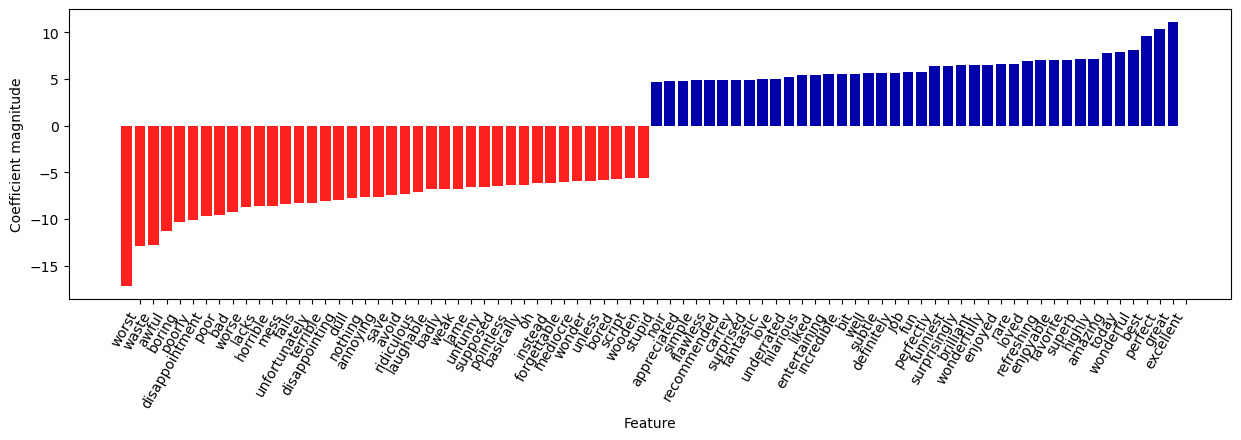

In [30]:
mglearn.tools.visualize_coefficients(
    grid.best_estimator_.named_steps["logisticregression"].coef_,
    feature_names, n_top_features=40)

## Bag-of-Words with More Than One Word (n-Grams)
>One of the main disadvantages of using a bag-of-words representation is that word order is completely discarded. Therefore, the two strings “it’s bad, not good at all” and “it’s good, not bad at all” have exactly the same representation, even though the meanings are inverted. Putting “not” in front of a word is only one example (if an extreme one) of how context matters. 

>Fortunately, there is a way of capturing context when using a bag-of-words representation, by not only considering the counts of single tokens, but also the counts of pairs or triplets of tokens that appear next to each other. 

>Pairs of tokens are known as bigrams, triplets of tokens are known as trigrams, and more generally sequences of tokens are known as n-grams. 

>We can change the range of tokens that are considered as features by changing the ngram_range parameter of CountVectorizer or TfidfVectorizer.

### Td-idf n-gram

**Note:** This grid search takes a long time to run

In [31]:
pipe = make_pipeline(TfidfVectorizer(min_df=5), LogisticRegression(max_iter=1500))
# running the grid search takes a long time because of the
# relatively large grid and the inclusion of trigrams
param_grid = {"logisticregression__C": [0.001, 0.01, 0.1, 1, 10, 100],
              "tfidfvectorizer__ngram_range": [(1, 1), (1, 2), (1, 3)]}

grid = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1)
grid.fit(text_train, y_train)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))
print("Best parameters:\n{}".format(grid.best_params_))

Best cross-validation score: 0.91
Best parameters:
{'logisticregression__C': 100, 'tfidfvectorizer__ngram_range': (1, 3)}


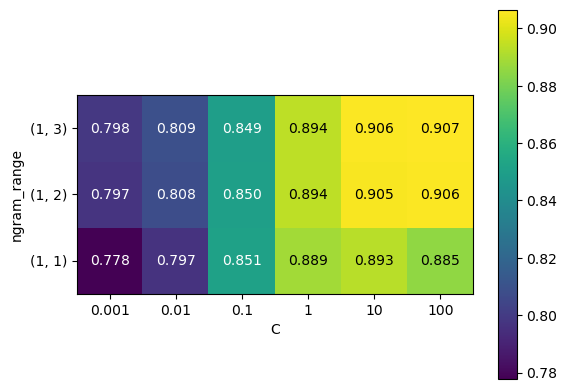

In [32]:
# extract scores from grid_search
scores = grid.cv_results_['mean_test_score'].reshape(-1, 3).T
# visualize heat map
heatmap = mglearn.tools.heatmap(
    scores, xlabel="C", ylabel="ngram_range", cmap="viridis", fmt="%.3f",
    xticklabels=param_grid['logisticregression__C'],
    yticklabels=param_grid['tfidfvectorizer__ngram_range'])
plt.colorbar(heatmap)

> From the heat map we can see that using bigrams or trigrams increases performance quite a bit compared to using unigrams. To understand better how the model improved, we can visualize the important coefficients for the best model, using unigrams, bigrams, and trigrams:

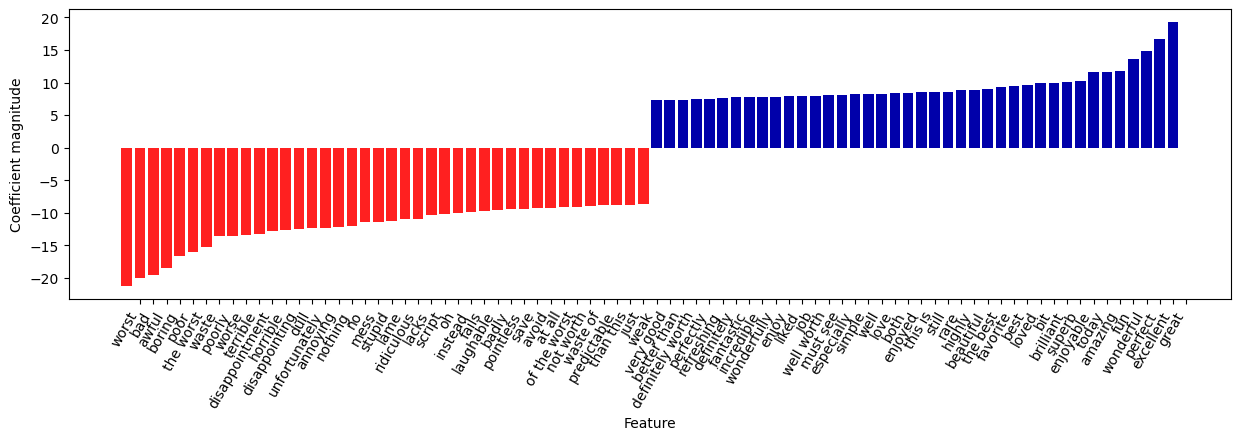

In [33]:
# extract feature names and coefficients
vect = grid.best_estimator_.named_steps['tfidfvectorizer']
feature_names = np.array(vect.get_feature_names_out())
coef = grid.best_estimator_.named_steps['logisticregression'].coef_
mglearn.tools.visualize_coefficients(coef, feature_names, n_top_features=40)

Coefficient magnitudes for trigram features are lower compared to the above plot. Hence, improvement is not as pronounced:

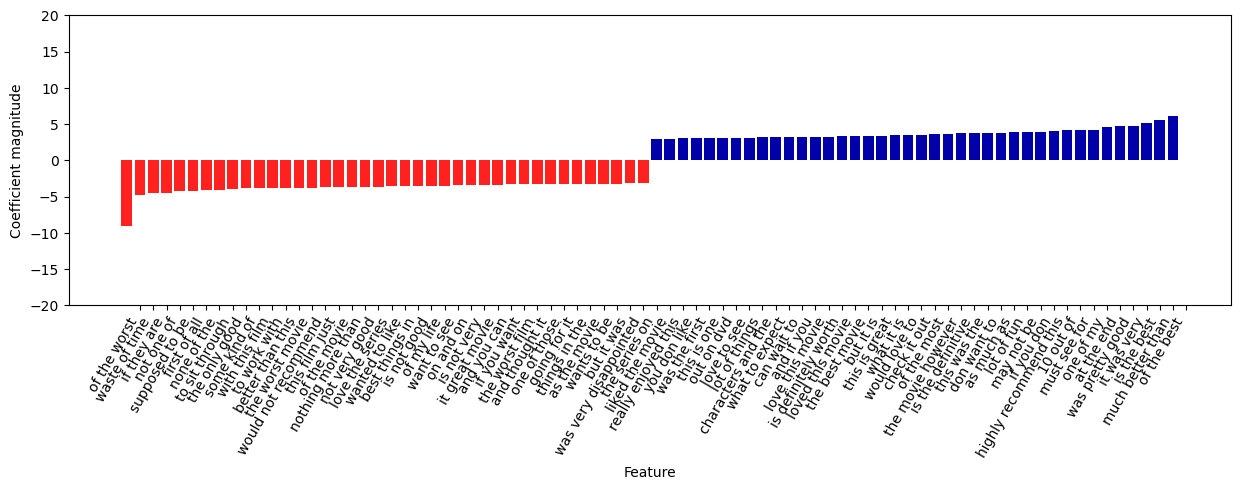

In [34]:
# find trigram features
mask = np.array([len(feature.split(" ")) for feature in feature_names]) == 3
# visualize only trigram features
mglearn.tools.visualize_coefficients(coef.ravel()[mask],
                                     feature_names[mask], n_top_features=40)
plt.ylim([-20, 20]);

## Save model to file

Since the trigram Tf-idf followed by LogisticRegression(C=100) worked the best, we can re-train this pipeline and save to file.


In [38]:
pipe = make_pipeline(TfidfVectorizer(min_df=5, ngram_range=(1, 3)), 
                     LogisticRegression(C=100, max_iter=1500))

pipe.fit(text_train, y_train)
pipe.score(text_test, y_test)

0.90208

In [39]:
from joblib import dump, load
dump(pipe, 'imdb-sentiment-classifier.joblib')

['imdb-sentiment-classifier.joblib']

In [40]:
clf = load('imdb-sentiment-classifier.joblib') 
print("Test-set score: {:.2f}".format(clf.score(text_test, y_test)))

Test-set score: 0.90
